In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

In [ ]:
cd drive/MyDrive/Datalab/practice

/content/drive/MyDrive/Datalab/practice


# data

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim


In [ ]:
df = pd.read_csv("../data/daily-median-income.csv")

In [ ]:
df = df.drop(columns=["Code"])

df = df.rename(columns={
    "Median (2021 prices)": "value"
})

In [ ]:
global_min_year = df["Year"].min()
global_max_year = df["Year"].max()

countries = df["Entity"].unique()
years = range(global_min_year, global_max_year + 1)

full_index = pd.MultiIndex.from_product(
    [countries, years],
    names=["Entity", "Year"]
)

df_full = (
    df
    .set_index(["Entity", "Year"])
    .reindex(full_index)
    .reset_index()
)


In [ ]:
df_full = df_full.sort_values(['Entity', 'Year'])


In [ ]:
df_full

,Entity,Year,value
0,Albania,1963,NaN
1,Albania,1964,NaN
2,Albania,1965,NaN
3,Albania,1966,NaN
4,Albania,1967,NaN
...,...,...,...
12154,Zimbabwe,2021,NaN
12155,Zimbabwe,2022,NaN
12156,Zimbabwe,2023,NaN
12157,Zimbabwe,2024,NaN


In [ ]:
import pandas as pd
import numpy as np

def fill_initial_and_intermediate(x):
    """
    x : pd.Series, 한 국가의 value 시계열
    - 초기 NaN 구간 → 최초 관측값
    - 중간 결측 → 선형 보간
    """
    # 1. 중간 결측 선형 보간
    x = x.interpolate(limit_direction='both')

    # 2. 초기 NaN → 최초 관측값
    if x.notna().any():
        first = x.dropna().iloc[0]
        x = x.fillna(method='ffill').fillna(first)

    return x


df_input = df_full.copy()

df_input['value'] = df_input.groupby('Entity')['value'].transform(
    fill_initial_and_intermediate
)

/tmp/ipython-input-4243775725.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = x.fillna(method='ffill').fillna(first)


In [ ]:
df_input

,Entity,Year,value
0,Albania,1963,7.419331
1,Albania,1964,7.419331
2,Albania,1965,7.419331
3,Albania,1966,7.419331
4,Albania,1967,7.419331
...,...,...,...
12154,Zimbabwe,2021,3.047864
12155,Zimbabwe,2022,3.047864
12156,Zimbabwe,2023,3.047864
12157,Zimbabwe,2024,3.047864


In [ ]:
observed_mask = (~df_full['value'].isna()).astype(float)


In [ ]:
entities = df_input['Entity'].unique()
years = sorted(df_input['Year'].unique())

values = []
masks = []

for ent in entities:
    sub = df_input[df_input['Entity'] == ent].set_index('Year').reindex(years)
    sub_mask = (~df_full[df_full['Entity'] == ent].set_index('Year').reindex(years)['value'].isna()).astype(float)

    values.append(sub['value'].values)
    masks.append(sub_mask.values)

observed_data = np.array(values)[..., None]  # (B, T, 1)
observed_mask = np.array(masks)[..., None]   # (B, T, 1)



In [ ]:

values = torch.tensor(np.array(values), dtype=torch.float32).to(device)
masks = torch.tensor(np.array(masks), dtype=torch.float32).to(device)


In [ ]:
!git clone https://github.com/ermongroup/CSDI.git

fatal: destination path 'CSDI' already exists and is not an empty directory.


In [ ]:
cd CSDI

/content/drive/MyDrive/Datalab/practice/CSDI


In [ ]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=65b150c7d9cbbbbab0c31b3073e244f8f2f62d0cc608608bc22e3886eb16a2d2
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
pwd

'/content/drive/MyDrive/Datalab/practice/CSDI'

In [ ]:
!pip install pyyaml

In [ ]:
import torch
import yaml
import numpy as np
from torch.utils.data import DataLoader, Dataset
from main_model import CSDI_Forecasting
from utils import train, evaluate
# YAML 읽기
with open("config/base_forecasting.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSDI_base(
    target_dim=1,
    config=config,
    device=device
).to(device)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(values, masks)
batch_size = config["train"]["batch_size"]  # YAML에서 가져오기

if values.ndim == 2:
    values = values.unsqueeze(-1)
if masks.ndim == 2:
    masks = masks.unsqueeze(-1)

train_dataset = ForecastingDataset(values, masks)
train_loader = DataLoader(train_dataset, batch_size=config["train"]["batch_size"], shuffle=True)
# train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [ ]:
target_dim = 1  # 예시로 1 설정

class ForecastingDataset(Dataset):
    def __init__(self, values, masks):
        """
        values: [Batch, Length, Feature]
        masks: [Batch, Length, Feature] (1은 관측됨, 0은 결측 혹은 예측대상)
        """
        self.values = values
        self.masks = masks

    def __getitem__(self, index):
        # CSDI_Forecasting.process_data가 기대하는 딕셔너리 구조
        return {
            "observed_data": self.values[index],
            "observed_mask": self.masks[index],
            "timepoints": torch.arange(self.values.shape[1]).float(),
            "gt_mask": self.masks[index],  # 예측 모델에서는 보통 관측된 부분이 조건(cond)이 됨
            "cut_length": torch.zeros(1).long()
        }

    def __len__(self):
        return len(self.values)

train_dataset = ForecastingDataset(values, masks)
train_loader = DataLoader(train_dataset, batch_size=config["train"]["batch_size"], shuffle=True)

# 3. 모델 선언 (CSDI_Forecasting 사용)
model = CSDI_Forecasting(config, device, target_dim=target_dim).to(device)

# 4. 학습 실행
# utils.py의 train 함수는 config에서 직접 lr과 epochs를 참조합니다.
config["lr"] = config["train"].get("lr", 1.0e-3)
config["epochs"] = config["train"].get("epochs", 100)
config["itr_per_epoch"] = len(train_loader)

train(
    model=model,
    config=config,
    train_loader=train_loader,
    foldername="save_model"  # 모델이 저장될 폴더
)

 96%|█████████▌| 24/25 [00:10<00:00,  2.39it/s, avg_epoch_loss=0, epoch=99]


RuntimeError: Parent directory save_model does not exist.

# 다시

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

# 1.1 데이터 피벗 (국가 x 연도 행렬 생성)
# index: 국가(Entity), columns: 연도(Year), values: 값(value)
pivot_df = df_full.pivot(index='Entity', columns='Year', values='value')
valid_years = pivot_df.columns[pivot_df.notna().mean() > 0.2]
pivot_df = pivot_df[valid_years]

# 1.2 실제 관측값 마스크 생성 (값이 있으면 1, NaN이면 0)
masks_np = (~pivot_df.isna()).astype(float).values

# 1.3 NaN 값을 0으로 채우기 (모델 입력용)
values_np = pivot_df.fillna(0).values

# 1.4 3차원 텐서로 변환 [Batch, Length, Feature]
# 현재 변수가 1개이므로 마지막에 unsqueeze(-1)를 해줍니다.
values_torch = torch.FloatTensor(values_np).unsqueeze(-1) # [국가수, 연도수, 1]
masks_torch = torch.FloatTensor(masks_np).unsqueeze(-1)   # [국가수, 연도수, 1]

print(f"Values shape: {values_torch.shape}") # 예: [150, 60, 1]

Values shape: torch.Size([193, 31, 1])


In [ ]:
class ForecastingDataset(Dataset):
    def __init__(self, values, masks):
        self.values = values
        self.masks = masks

    def __getitem__(self, index):
        return {
            "observed_data": self.values[index],
            "observed_mask": self.masks[index],
            "gt_mask": self.masks[index],  # 실제 관측된 모든 곳을 정답지로 설정
            "timepoints": torch.arange(self.values.shape[1]).float(),
            "cut_length": torch.zeros(1).long()
        }

    def __len__(self):
        return len(self.values)

# 데이터로더 생성
batch_size = config["train"]["batch_size"] # YAML 파일 설정값
train_dataset = ForecastingDataset(values_torch, masks_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
import yaml
from main_model import CSDI_Forecasting

# 3.1 YAML 로드
with open("config/base_forecasting.yaml", "r") as f:
    config = yaml.safe_load(f)


config["lr"] = config["train"]["lr"]
config["epochs"] = config["train"]["epochs"]
config["itr_per_epoch"] = len(train_loader)

# [핵심] Loss가 0이 나오지 않게 하려면 여기서 "random"으로 바꿔야 합니다.
config["model"]["target_strategy"] = "random"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 3.2 모델 선언
target_dim = values_torch.shape[-1] # 변수 개수 (여기서는 1)
model = CSDI_Forecasting(config, device, target_dim=target_dim).to(device)

In [ ]:
from utils import train


def force_random_mask(observed_mask, gt_mask):
    return model.get_randmask(observed_mask)

model.get_test_pattern_mask = force_random_mask
# ----------------------------------
# test_batch = next(iter(train_loader))
# model.train()
# loss = model(test_batch)
# test_batch = next(iter(train_loader))
# model.train()
# loss = model(test_batch)
print(f"설정된 학습 전략: {model.target_strategy}") # 'random'이 출력되어야 함

# 5. 테스트 배치로 Loss 체크
model.train()
test_batch = next(iter(train_loader))
loss = model(test_batch)
print(f"테스트 배치 Loss: {loss.item()}") # 0이 아닌 숫자가 나오는지 확인

folder_name = "save_model_output"

# 2. 폴더가 없으면 생성 (이미 있으면 무시)
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Directory {folder_name} created!")

# 4.2 학습 시작
train(
    model=model,
    config=config,
    train_loader=train_loader,
    foldername="save_model_output" # 학습된 모델(.pth)이 저장될 폴더
)

설정된 학습 전략: random
테스트 배치 Loss: 1.211244821548462
Directory save_model_output created!


 96%|█████████▌| 24/25 [00:01<00:00, 16.43it/s, avg_epoch_loss=0.682, epoch=99]


In [ ]:
def fill_missing_values(model, dataset, n_samples=5):
    model.eval()
    all_filled_data = []

    # 셔플하지 않고 순서대로 가져옵니다.
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            # model.evaluate는 튜플을 반환합니다.
            # 첫 번째 요소인 samples가 [n_samples, batch, length, feature] 텐서입니다.
            output = model.evaluate(batch, n_samples)
            samples = output[0] # 튜플에서 첫 번째 결과물만 추출

            # n_samples 시나리오들에 대해 중앙값 계산
            # samples: [100, 1, 61, 1] -> median_value: [1, 61, 1]
            median_value = samples.median(dim=0).values

            # 장치(GPU/CPU) 맞추기
            observed = batch["observed_data"].to(device)
            mask = batch["observed_mask"].to(device)

            # 실제 값(mask 1)은 유지, 결측치(mask 0)만 생성된 값으로 채움
            filled = observed * mask + median_value * (1 - mask)
            all_filled_data.append(filled.cpu().numpy())

    return np.concatenate(all_filled_data, axis=0)

# 실행
filled_data = fill_missing_values(model, train_dataset)

In [ ]:
filled_data

array([[[ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967],
        [ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967],
        [ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967],
        ...,
        [ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967],
        [ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967],
        [ 26.432041 ,   5.72678  ,   7.0816503, ...,   5.8368063,
          22.018503 ,   3.1297967]],

       [[  2.1593406,   2.8623426,   2.486552 , ..., 112.58485  ,
          52.272648 ,  51.802185 ],
        [  2.1593406,   2.8623426,   2.486552 , ..., 112.58485  ,
          52.272648 ,  51.802185 ],
        [  2.1593406,   2.8623426,   2.486552 , ..., 112.58485  ,
          52.272648 ,  51.802185 ],
        ...,
        [  2.1593406,   2.8623426,   2.486552 , ..., 1

In [ ]:
import pandas as pd
import numpy as np

# 1. 차원 및 크기 확인
print(f"원본 filled_data 모양: {filled_data.shape}") # 아마 (965, 31, 1) 또는 (965, 31) 일 것입니다.

# 2. n_samples로 인해 늘어난 데이터를 국가 수(193)에 맞게 재정렬
num_entities = len(pivot_df.index)  # 193
num_years = len(pivot_df.columns)   # 31

# 만약 데이터가 (국가 * 샘플수, 연도) 형태로 쌓여 있다면,
# 이를 (샘플수, 국가, 연도)로 reshape한 뒤 평균을 내야 합니다.
try:
    # (965, 31) -> (5, 193, 31) 형태로 분리 (5는 n_samples)
    reshaped_data = filled_data.reshape(-1, num_entities, num_years)
    # 샘플들의 평균(또는 중앙값)을 내어 (193, 31)로 만듭니다.
    final_2d = np.mean(reshaped_data, axis=0)
    print(f"변환 후 데이터 모양: {final_2d.shape}") # (193, 31)이 되어야 함
except Exception as e:
    print("Reshape 중 오류 발생, 단일 슬라이싱 시도...")
    final_2d = filled_data[:num_entities, :num_years]

# 3. 데이터프레임 생성
df_imputed_table = pd.DataFrame(
    final_2d,
    index=pivot_df.index,
    columns=pivot_df.columns
)

# 4. 긴 형태로 변환 (Stack) 및 병합
df_imputed_long = df_imputed_table.stack().reset_index()
df_imputed_long.columns = ['Entity', 'Year', 'value_csdi']

df_final = pd.merge(df_full, df_imputed_long, on=['Entity', 'Year'], how='left')
df_final['value_final'] = df_final['value'].fillna(df_final['value_csdi'])

print("데이터 복구 성공!")

원본 filled_data 모양: (965, 31, 31)
변환 후 데이터 모양: (193, 31)
데이터 복구 성공!


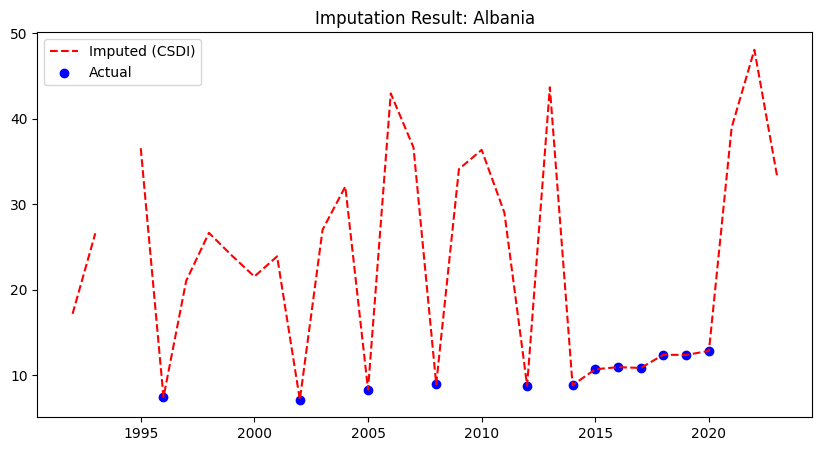

In [ ]:
import matplotlib.pyplot as plt

def quick_plot(country_name):
    # 해당 국가 데이터 필터링
    c_data = df_final[df_final['Entity'] == country_name].sort_values('Year')

    plt.figure(figsize=(10, 5))
    # 모델이 채운 값
    plt.plot(c_data['Year'], c_data['value_final'], 'r--', label='Imputed (CSDI)')
    # 원래 있던 값
    plt.scatter(c_data['Year'], c_data['value'], color='blue', label='Actual')

    plt.title(f"Imputation Result: {country_name}")
    plt.legend()
    plt.show()

# 첫 번째 국가로 테스트
quick_plot(df_final['Entity'].unique()[0])

In [ ]:
from sklearn.metrics import mean_squared_error

# 1. 실제 값(value)과 모델 예측값(value_csdi)이 모두 있는 행만 추출
eval_df = df_final.dropna(subset=['value', 'value_csdi'])

# 2. 데이터가 비어있지 않은지 확인 후 계산
if len(eval_df) > 0:
    rmse = np.sqrt(mean_squared_error(eval_df['value'], eval_df['value_csdi']))
    print(f"평가에 사용된 데이터 개수: {len(eval_df)}개")
    print(f"최종 RMSE: {rmse:.4f}")
else:
    print("평가할 수 있는 데이터가 없습니다. 병합 과정을 확인하세요.")

평가에 사용된 데이터 개수: 2383개
최종 RMSE: 25.8056


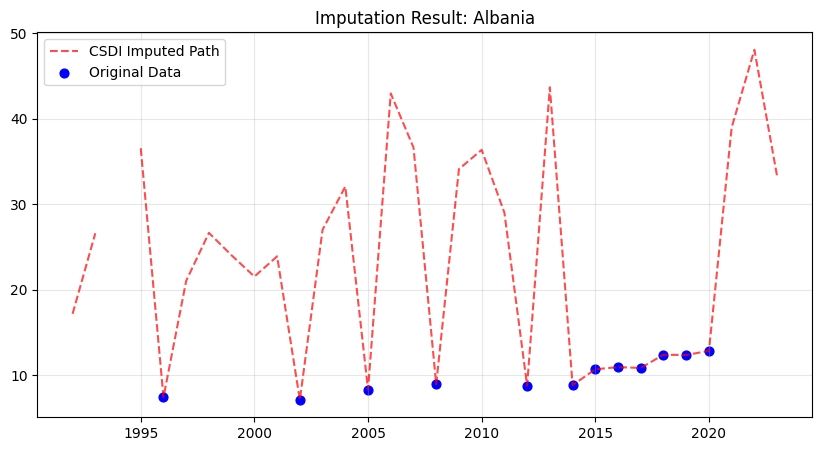

In [ ]:
import matplotlib.pyplot as plt

def plot_final(country):
    # 데이터 추출 및 정렬
    data = df_final[df_final['Entity'] == country].sort_values('Year')

    if data.empty:
        print(f"{country} 데이터를 찾을 수 없습니다.")
        return

    plt.figure(figsize=(10, 5))

    # 모델이 예측한 값 (결측치 포함 전체 흐름)
    plt.plot(data['Year'], data['value_final'], 'r--', label='CSDI Imputed Path', alpha=0.7)

    # 실제 데이터 지점 (원본)
    observed = data.dropna(subset=['value'])
    plt.scatter(observed['Year'], observed['value'], color='blue', label='Original Data', s=40)

    plt.title(f"Imputation Result: {country}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 샘플 국가 하나 그려보기
plot_final(df_final['Entity'].unique()[0])